In [ ]:
import numpy as np
from scipy.optimize import curve_fit

from theia.detection.active import calculate_probability_of_detection


def sigmoid(x, x0, k):
    return 1 / (1 + np.exp(-k * (x - x0)))


def richards(x, x0, k, nu):
    return 1 / (1 + np.exp(-k * (x - x0))) ** (1 / nu)


def two_sided(x, x0, k_lo, k_hi, nu_lo, nu_hi):
    k = np.where(x < x0, k_lo, k_hi)
    nu = np.where(x < x0, nu_lo, nu_hi)
    return 1 / (1 + np.exp(-k * (x - x0))) ** (1 / nu)


# your data
snrs = np.linspace(-10, 20, 301)
pdfs = np.array([calculate_probability_of_detection(snr, 1e-6) for snr in snrs])

x0_guess = 11.5
k_guess = 1
nu_guess = 1

# popt, pcov = curve_fit(sigmoid, snrs, pdfs, p0=[x0_guess, k_guess])
popt, pcov = curve_fit(richards, snrs, pdfs, p0=[x0_guess, k_guess, nu_guess])
fit_x0, fit_k, fit_nu = popt
fit_x0, fit_k, fit_nu
max((pdfs - richards(snrs, fit_x0, fit_k, fit_nu)) * 100)

k_lo_guess = 1
k_high_guess = 1
nu_lo_guess = 1
nu_high_guess = 1
popt, pcov = curve_fit(
    two_sided,
    snrs,
    pdfs,
    p0=[x0_guess, k_lo_guess, k_high_guess, nu_lo_guess, nu_high_guess],
)
fit_x0, fit_k_lo, fit_k_high, fit_nu_low, fit_nu_high = popt
max(
    (pdfs - two_sided(snrs, fit_x0, fit_k_lo, fit_k_high, fit_nu_low, fit_nu_high))
    * 100
)

In [ ]:
from scipy.stats import ncx2

def pd_exact(snr, pfa):
    """Vectorized, exact probability of detection via noncentral chi-squared."""
    alpha = 10 ** ((snr + 3) / 20)
    beta = np.sqrt(-2 * np.log(pfa))
    pd = ncx2.sf(beta**2, df=2, nc=alpha**2)
    return np.where(alpha > 30, 1.0, pd)

In [ ]:
%%timeit
two_sided(7, fit_x0, fit_k_lo, fit_k_high, fit_nu_low, fit_nu_high)

In [ ]:
%%timeit
pd_exact(7,  1e-6)

In [ ]:
%%timeit
fast_pd(7)

In [2]:
%%timeit
calculate_probability_of_detection(7, 1e-6)

322 ns ± 13 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


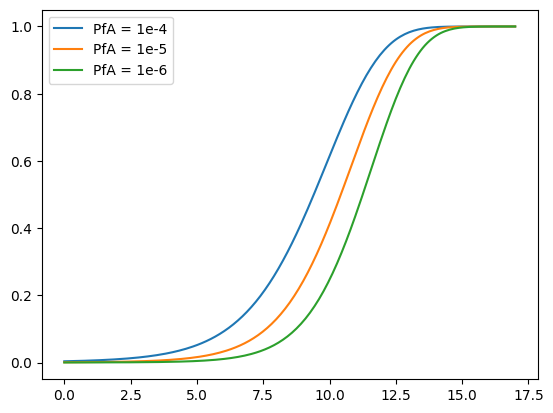

In [1]:
from matplotlib import pyplot as plt
import numpy as np

from theia.detection.active import calculate_probability_of_detection


snrs = np.linspace(0, 17, 201)

fig, ax = plt.subplots()

for p in [1e-4, 1e-5, 1e-6]:
    ps = [calculate_probability_of_detection(snr, p) for snr in snrs]
    ax.plot(snrs, ps, label=f"PfA = 1e{np.log10(p):.0f}")
ax.legend();
# ax.set_yscale("log")

In [ ]:
from theia.detection.active import FastPd


fast_pd = FastPd(-10, 20, 301, 1e-6)

In [ ]:
fig, ax = plt.subplots()

# ax.plot(snrs, pdfs, label="ground truth")
# ax.plot(snrs, pd_exact(snrs, 1e-6), label="Fast exact")
# ax.plot(
#     snrs,
#     two_sided(snrs, fit_x0, fit_k_lo, fit_k_high, fit_nu_low, fit_nu_high),
#     label="Two sided",
# )
ax.plot(
    snrs,
    (pdfs - [fast_pd(snr) for snr in snrs])
    * 100,
)
# ax.plot(snrs, pdfs - pd_exact(snrs, 1e-6), label="diff")
ax.legend()

In [ ]:
%%timeit
calculate_probability_of_detection(7, 1e-6)

In [ ]:
import json

from theia.simulation.scenario_import import OrderOfBattle

with open("scenarios/FLORAKO.orbat.json", "r") as file:
    orbat = OrderOfBattle.model_validate_json(file.read())

In [ ]:
from theia.config import DEFAULT_TERRAIN
from theia.simulation.scenario_import import TerrainFactory
from theia.coverage import calculate_coverage
from theia.radar_equation import calculate_maximum_monostatic_range


s = orbat.monostatic_sensors[0].sensor
terrain = TerrainFactory(terrain_name=DEFAULT_TERRAIN).to_terrain()

In [ ]:
%%timeit
d_max = calculate_maximum_monostatic_range(s, 1.0)
cov = calculate_coverage(terrain, s.receiver.point, d_max, 10000)

In [ ]:
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation

from theia.distance import burstvincentydistance, line_of_sight_distance
from theia.grids import LatLonHeightGrid
from theia.terrain import AbstractTerrainModel
from theia.types import MonostaticSensor, Point


def calculate_coverage_new(
    sensor: MonostaticSensor,
    terrain: AbstractTerrainModel,
    target_rcs: float,
    target_alt: float,
    dlat: float,
    dlon: float,
):
    # TODO
    d_max = calculate_maximum_monostatic_range(s, target_rcs)
    p = (sensor.receiver.lat, sensor.receiver.lon)
    north = burstvincentydistance(p, d_max, 0, target_alt)
    east = burstvincentydistance(p, d_max, 90, target_alt)
    south = burstvincentydistance(p, d_max, 180, target_alt)
    west = burstvincentydistance(p, d_max, 270, target_alt)
    grid = LatLonHeightGrid(
        lat_start=south.lat,
        lat_stop=north.lat + dlat,
        lat_res=dlat,
        lon_start=west.lon,
        lon_stop=east.lon + dlon,
        lon_res=dlon,
        height_start=target_alt,
        height_stop=target_alt,
        height_res=1,
    )

    return _calculate_monostatic_coverage(sensor, terrain, target_rcs, grid, d_max)


def _calculate_monostatic_coverage(
    sensor: MonostaticSensor,
    terrain: AbstractTerrainModel,
    target_rcs: float,
    grid: LatLonHeightGrid,
    d_max: float,
) -> np.ndarray:
    points = grid.points
    mask = np.empty((points.shape[0],), dtype=bool)
    for i, p in enumerate(points):
        # Distance check: We have a rectangular grid!
        mask[i] = line_of_sight_distance(
            sensor.receiver.lat,
            sensor.receiver.lon,
            sensor.receiver.alt,
            p[0],
            p[1],
            p[2],
        ) <= d_max and terrain.has_line_of_sight(
            sensor.receiver.point,
            Point(lat=p[0], lon=p[1], alt=p[2]),
        )
    mask = mask.reshape(grid.n_points[:2])
    mask = binary_dilation(binary_erosion(mask))

    from theia.util import mask_to_polygon

    return mask, mask_to_polygon(
        mask,
        grid.lat_start,
        grid.lat_res,
        grid.lon_start,
        grid.lon_res,
    )

In [ ]:
rcs = 1.0
alt = 3_000
d_max = calculate_maximum_monostatic_range(s, rcs)
print(d_max)
cov = calculate_coverage(terrain, s.receiver.point, d_max, alt)
cov

In [ ]:
from matplotlib import pyplot as plt

import cProfile


profiler = cProfile.Profile()

profiler.enable()

mask, cov_new = calculate_coverage_new(s, terrain, rcs, alt, 0.025, 0.05)

profiler.disable()
profiler.dump_stats("profile_coverage.prof")

# cProf


# def is_small(polygon):
#     return

# cov_new[4].bounds
# polygon = cov_new[4]

# polygon.bounds[2] - polygon.bounds[0], polygon.bounds[3] - polygon.bounds[1]

In [ ]:
cov_new[0]

In [ ]:
cov

In [ ]:
import folium


m = folium.Map()
folium.GeoJson(cov).add_to(m)
folium.GeoJson(cov_new[0], color="orange").add_to(m)
m

In [ ]:
cov.difference(cov_new[0])

In [ ]:
%%timeit
cov_new = calculate_coverage_new(s, terrain, 1.0, 1000.0, 0.05, 0.05)

In [ ]:
%%timeit
d_max = calculate_maximum_monostatic_range(s, 1.0)
cov = calculate_coverage(terrain, s.receiver.point, d_max, 1000)

In [ ]:
cov

In [ ]:
from theia.detection.active import calculate_probability_of_detection

rng = np.random.default_rng(seed=97497)
p1 = terrain.sample_location(rng, 46, 48, 9, 10)
p2 = terrain.sample_location(rng, 46, 48, 9, 10)
snrs = np.linspace(0, 50, 50)

In [ ]:
%%timeit
terrain.has_line_of_sight(p1, p2)

In [ ]:
%%timeit
r = calculate_probability_of_detection(0, 1e-6)

In [ ]:
4.61 / 50

In [ ]:
with open("scenarios/fest_mw_59.orbat.json", "r") as file:
    orbat = OrderOfBattle.model_validate_json(file.read())

In [ ]:
with open("scenarios/drone_attack_on_ZRH.orbat.json", "r") as file:
    orbat = OrderOfBattle.model_validate_json(file.read())

In [ ]:
with open("scenarios/ballistic_missile_kaliningrad-bern.orbat.json", "r") as file:
    orbat = OrderOfBattle.model_validate_json(file.read())

In [ ]:
from theia.terrain import SrtmTerrainModel

orbat.to_controller(SrtmTerrainModel(), False)

In [ ]:
from theia.simulation.theia_logging import LogLoader

loader = LogLoader("scenarios/fest_mw_drones/result_full_sensors.json")

In [ ]:
import pandas as pd

set([type(e) for e in loader._events])

In [ ]:
from theia.coordinates import CoordinateTransformations

s = loader._snapshots[-2]
s.time, s.red_targets
# CoordinateTransformations.cartesian_to_geodetic(
#     *loader.red_target_ground_truth[0].states[-1].state_vector[[0, 2, 4]]
# )

In [ ]:
from theia.config import TERRAIN_HBV_DATA_DIR
from theia.terrain_fast_los import FastSrtmModel, HbvTree

tree = HbvTree.load(
    rf"{TERRAIN_HBV_DATA_DIR}/tree_lat46:49_lon7:11_subsamplestride2.zip"
)

In [ ]:
import folium

from theia.terrain import SrtmTerrainModel

terrain = SrtmTerrainModel()
rects = terrain.covered_region()

BLUE_INFRA_LAT = 47.45270
BLUE_INFRA_LON = 8.56068

m = folium.Map((46.9552, 8.0322), zoom_start=8)
folium.LatLngPopup().add_to(m)
for rect in rects:
    folium.GeoJson(rect.model_dump_json(), tooltip=rect.properties["name"]).add_to(m)
folium.Rectangle(((46, 7), (49, 11)), color="red").add_to(m)
folium.Circle((BLUE_INFRA_LAT, BLUE_INFRA_LON), radius=150_000, color="orange").add_to(
    m
)
m

In [ ]:
import json

import pandas as pd
from pyproj import Transformer

from theia.simulation.scenario_import import (
    DirectFireEffectorFactory,
    StaticDispositive,
    TerrainFactory,
)
from theia.types import Point

terrain = SrtmTerrainModel()

df = pd.read_csv("~/Downloads/standorte_fest_mw_prinzipskizze.csv")
df = (
    df.reset_index()
    .rename(columns={"index": "ID", "x": "LV95 easting", " y": "LV95 northing"})
    .set_index("ID")
)

# LV95 = EPSG:2056, WGS84 = EPSG:4326
transformer = Transformer.from_crs("EPSG:2056", "EPSG:4326", always_xy=True)

for i, row in df.iterrows():
    lon, lat = transformer.transform(row["LV95 easting"], row["LV95 northing"])
    df.loc[i, "lat"] = lat
    df.loc[i, "lon"] = lon

df.to_csv("standorte_fest_mw_prinzipskizze_annotated.csv")

effectors: list[DirectFireEffectorFactory] = []
for id, row in df.iterrows():
    effectors.append(
        DirectFireEffectorFactory(
            id=id,
            name=f"Fest Mw {id}",
            point=Point(
                lat=row["lat"],
                lon=row["lon"],
                alt=terrain.elevationAt(row["lat"], row["lon"]),
            ),
            combat_range=8_000,
            n_attacks_left=3_500,
            terrain=TerrainFactory(
                terrain_name="tree_lat46:49_lon7:11_subsamplestride2"
            ),
        )
    )

deployment = {
    "monostatic_sensors": [],
    "pcl_sensors": [],
    "effectors": [e.model_dump() for e in effectors],
}

with open("scenarios/fest_mw.static_dispositive.json", "w") as file:
    json.dump(deployment, file)

In [ ]:
from theia.simulation.scenario_import import (
    DirectFireEffectorFactory,
    StaticDispositive,
    TerrainFactory,
)

dispo = StaticDispositive.from_file("scenarios/fest_mw.static_dispositive.json")

In [ ]:
import folium

m = folium.Map((46.9552, 8.0322), zoom_start=8)
folium.LatLngPopup().add_to(m)
for ID, row in df.iterrows():
    p = (row["lat"], row["lon"])
    folium.Marker(p, tooltip=f"#{ID}").add_to(m)
    folium.Circle(p, radius=8_000).add_to(m)
m

In [ ]:
m.save("festungsminenwerfer_prinzipskizze.html")

In [ ]:
# TODO
# Ballistic missile, e. g. PrSM


# Cruise Missile
# Iskander M
# https://handwiki.org/wiki/Engineering:9K720_Iskander

In [ ]:
# import numpy as np
# from scipy.constants import gravitational_constant

# omega = 0.0
# """Earth rotation rate"""
# G = gravitational_constant
# M = 5.972 * 1e24
# """Mass of earth [kg]"""
# r0 = 1.0
# mu = 0.0
# """Geodetic latitude of radar [°]"""
# rho = 0.0
# g = 9.81
# beta = 1.0
# V0 = 1.0
# R = 1.0
# V = 1.0
# r = 1.0
# J = 1.0
# a = 1.0
# phi = 1.0
# mu_c = 1.0
# """Geocentric latitude of radar [°]"""

# # State vector:
# # x, y, z, vx, vy, vz
# x = np.ones(6)


# A_top_left = np.zeros((3, 3))
# A_top_right = np.eye(3)
# # fmt: off
# tmp1 = -omega ** 2 * np.sin(mu) * np.cos(mu)
# tmp2 = - rho * g / (2 * beta) * V0

# A_bottom_left = np.array([
#     [omega**2 - G * M / r0**3,                                      0.0, 0.0],
#     [                     0.0, omega**2 * np.sin(mu)**2 - G * M / r0**3,                                      tmp1],
#     [                     0.0,                                      tmp1, omega**2 * np.cos(mu)**2 - G * M / r0**3],
# ])

# A_bottom_right = np.array([
#     [                   tmp2, 2 * omega * np.sin(mu), -2 * omega * np.cos(mu)],
#     [-2 * omega * np.sin(mu),                   tmp2,                     0.0],
#     [ 2 * omega * np.cos(mu),                    0.0,                    tmp2],
# ])

# A = np.block(
#     [
#         [A_top_left, A_top_right],
#         [A_bottom_left, A_bottom_right],
#     ]
# )

# B = np.array(
#     [
#         0.0,
#         0.0,
#         0.0,
#         0.0,
#         -(omega**2) * R * np.sin(mu) * np.cos(mu),
#         omega**2 * R * np.cos(mu) ** 2 - G * M * R / r0**3,
#     ]
# )

# C = np.array(
#     [
#         0.0,
#         0.0,
#         0.0,
#         rho * g / (2 * beta) * (V0 - V) * x[3] + G * M * (1 / r0**3 - 1 / r**3) * x[0],
#         rho * g / (2 * beta) * (V0 - V) * x[4] + G * M * (1 / r0**3 - 1 / r**3) * x[1],
#         rho * g / (2 * beta) * (V0 - V) * x[5] + G * M * (1 / r0**3 - 1 / r**3) * (x[2] + R),
#     ]
# )

# D = np.array(
#     [
#         0.0,
#         0.0,
#         0.0,
#         - G * M / r**3 * J * (a / r)**2 * (1.0 - 5 * np.sin(phi) ** 2) * x[0],
#         - G * M / r**3 * J * (a / r)**2 * (1.0 - 5 * np.sin(phi) ** 2) * x[1] - 2 * G * M / r**2 * J * (a / r)**2 * np.sin(phi) * np.cos(mu) \
#             - R * omega**2 * np.sin(mu) * (np.cos(mu) * (np.cos(mu - mu_c) - 1) - np.sin(mu) * np.sin(mu - mu_c)) \
#             + G * M / r**3 * R * np.sin(mu - mu_c) * (J * (a / r)**2 * (1.0 - 5 * np.sin(phi)**2) + 1.0),
#         - G * M / r**3 * J * (a / r)**2 * (1.0 - 5 * np.sin(phi) ** 2) * (x[2] + R * np.cos(mu - mu_c)) - 2 * G * M / r**2 * J * (a / r)**2 * np.sin(phi) * np.cos(mu) \
#             + R * omega**2 * np.cos(mu) * (np.cos(mu) * (np.cos(mu - mu_c) - 1) + np.sin(mu) * np.sin(mu - mu_c)) \
#             - G * M / r**3 * R * (np.cos(mu - mu_c) - 1),
#     ]
# )
# # fmt: on

In [ ]:
from theia.terrain import SrtmTerrainModel

terrain = SrtmTerrainModel()

In [ ]:
from theia.types import Point

THEATER_LAT_MIN = 46.3805
THEATER_LON_MIN = 9.2207
THEATER_LAT_MAX = 47.2440
THEATER_LON_MAX = 10.4790

# Source:
# AIRAC AIP SUP: 008/2025
# https://www.skybriefing.com/documents/10156/531923/LS_Sup_A_2025_008_en.pdf/9383f427-aee4-73e5-2f58-f6c49c721bc8?t=1766406342056
# Retrieved 2026-07-02.

NM_TO_M = 1852
FEET_TO_M = 0.3048

DAVOS_LAT = 46.81472
DAVOS_LON = 9.84944
RADIUS_RESTRICTED_AREA = 25 * NM_TO_M  # [m]
RADIUS_DAVOS_CONTROL_ZONE = 2.7 * NM_TO_M  # [m]
HEIGHT_RESTRICTED_AREA = 19500 * FEET_TO_M  # [m]

davos = Point(
    lat=DAVOS_LAT,
    lon=DAVOS_LON,
    alt=terrain.elevationAt(DAVOS_LAT, DAVOS_LON),
)

In [ ]:
import json

import folium

data_dir = "/home/user/Documents/theia_backend/examples/conference/data"

with open(f"{data_dir}/LS-R90.geojson", "r") as file:
    lsr90 = json.load(file)

with open(f"{data_dir}/flight-path-spacetime_authorized.json", "r") as file:
    data_authorized = json.load(file)

with open(f"{data_dir}/flight-path-spacetime_adversarial.json", "r") as file:
    data_adversarial = json.load(file)


flight_path_green = folium.PolyLine(
    [(p["lat"], p["lon"]) for p in data_authorized if p["time"] <= 1550],
    tooltip="Normal flight",
    color="green",
)
flight_path_green_planned = folium.PolyLine(
    [(p["lat"], p["lon"]) for p in data_authorized if p["time"] > 1550],
    tooltip="Normal flight (authorized)",
    color="green",
    dashArray="5, 5",
)
flight_path_red = folium.PolyLine(
    [(p["lat"], p["lon"]) for p in data_adversarial if p["time"] > 1550],
    tooltip="Unauthorized change of plan: RED!",
    color="red",
)

In [ ]:
import folium

highlight_waypoints = [
    "AKABI",
    "BODAN",
    "LAGOS",
    "VEBEG",
    "EBUXA",
    "ARGAX",
]


map = folium.Map(location=(DAVOS_LAT, DAVOS_LON), zoom_start=9)
folium.LatLngPopup().add_to(map)
folium.Rectangle(
    [
        (THEATER_LAT_MIN, THEATER_LON_MIN),
        (THEATER_LAT_MAX, THEATER_LON_MAX),
    ],
    tooltip="Theater",
    color="black",
).add_to(map)

folium.GeoJson(
    lsr90,
    tooltip="TEMPO LS-R90",
    fill=False,
    color="orange",
).add_to(map)
folium.Circle(
    location=(DAVOS_LAT, DAVOS_LON),
    radius=RADIUS_DAVOS_CONTROL_ZONE,
    tooltip="CTR",
    color="darkred",
).add_to(map)

folium.Marker(
    flight_path_green.locations[-1],
    tooltip="Transponder off",
    icon=folium.Icon(icon="power-off", prefix="fa", color="red"),
).add_to(map)

# folium.Marker((points[:, :, :, 0].min(), points[:, :, :, 1].min())).add_to(map)
# folium.Marker((points[:, :, :, 0].max(), points[:, :, :, 1].max())).add_to(map)
flight_path_green.add_to(map)
flight_path_green_planned.add_to(map)
flight_path_red.add_to(map)

map

In [ ]:
from theia.coordinates import CoordinateTransformations, EcefToEnuTransformer
from theia.grids import EnuGridMask

transformer = EcefToEnuTransformer(reference_point=davos)
p_northeast_enu = transformer.ecef_to_enu(
    CoordinateTransformations.geodetic_to_cartesian(
        THEATER_LAT_MAX,
        THEATER_LON_MAX,
        0.0,
    )
)
p_southwest_enu = transformer.ecef_to_enu(
    CoordinateTransformations.geodetic_to_cartesian(
        THEATER_LAT_MIN,
        THEATER_LON_MIN,
        0.0,
    )
)

davos_enu = transformer.ecef_to_enu(
    CoordinateTransformations.geodetic_to_cartesian(
        davos.lat,
        davos.lon,
        davos.alt,
    )
)

RES_NORTH_EAST = 100.0
RES_UP = 100.0

grid = EnuGridMask(
    reference_point=davos,
    east_min=p_southwest_enu[0],
    east_max=p_northeast_enu[0],
    north_min=p_southwest_enu[1],
    north_max=p_northeast_enu[1],
    up_min=davos_enu[2],
    up_max=davos_enu[2] + 1500,
    res_north_east=RES_NORTH_EAST,
    res_up=RES_UP,
    terrain=terrain,
)
mask = grid.binary_mask
points = grid.points

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(8, 9))

for i, ax in enumerate(axes.flatten()):
    ax.imshow((mask[:, :, i]))
    ax.set_title(f"Up = {i * RES_UP}m")
    ax.invert_yaxis()
    ax.set_xlabel(f"East [{RES_NORTH_EAST} m]")
    ax.set_ylabel(f"North [{RES_NORTH_EAST} m]")

fig.tight_layout()

In [ ]:
import numba


@numba.njit(cache=True)
def _bfs_shortest_path(occ, start, stop, connectivity):
    nx, ny, nz = occ.shape
    n = nx * ny * nz

    visited = np.zeros(n, dtype=np.bool_)
    prev = np.full(n, -1, dtype=np.int64)
    queue = np.empty(n, dtype=np.int64)
    q_head = 0
    q_tail = 0

    sx, sy, sz = start[0], start[1], start[2]
    ex, ey, ez = stop[0], stop[1], stop[2]

    if occ[sx, sy, sz] or occ[ex, ey, ez]:
        return np.empty(0, dtype=np.int64), False

    s_idx = (sx * ny + sy) * nz + sz
    e_idx = (ex * ny + ey) * nz + ez

    visited[s_idx] = True
    queue[q_tail] = s_idx
    q_tail += 1

    if connectivity == 6:
        dxs = np.array([1, -1, 0, 0, 0, 0], dtype=np.int64)
        dys = np.array([0, 0, 1, -1, 0, 0], dtype=np.int64)
        dzs = np.array([0, 0, 0, 0, 1, -1], dtype=np.int64)
    else:  # 26-connectivity
        dxs = np.empty(26, dtype=np.int64)
        dys = np.empty(26, dtype=np.int64)
        dzs = np.empty(26, dtype=np.int64)
        c = 0
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                for dz in (-1, 0, 1):
                    if dx == 0 and dy == 0 and dz == 0:
                        continue
                    dxs[c] = dx
                    dys[c] = dy
                    dzs[c] = dz
                    c += 1

    found = False
    while q_head < q_tail:
        cur = queue[q_head]
        q_head += 1

        if cur == e_idx:
            found = True
            break

        cz = cur % nz
        cy = (cur // nz) % ny
        cx = cur // (ny * nz)

        for k in range(dxs.shape[0]):
            nxp = cx + dxs[k]
            nyp = cy + dys[k]
            nzp = cz + dzs[k]

            if 0 <= nxp < nx and 0 <= nyp < ny and 0 <= nzp < nz:
                nidx = (nxp * ny + nyp) * nz + nzp
                if (not visited[nidx]) and (not occ[nxp, nyp, nzp]):
                    visited[nidx] = True
                    prev[nidx] = cur
                    queue[q_tail] = nidx
                    q_tail += 1

    if not found:
        return np.empty(0, dtype=np.int64), False

    # reconstruct path length first, then fill backward
    path_len = 1
    node = e_idx
    while node != s_idx:
        node = prev[node]
        path_len += 1

    path = np.empty(path_len, dtype=np.int64)
    node = e_idx
    for i in range(path_len - 1, -1, -1):
        path[i] = node
        if node != s_idx:
            node = prev[node]

    return path, True


def shortest_path(occ, start, stop, connectivity=6):
    """
    Shortest path between two voxels in a 3D binary occupancy grid (BFS).

    Parameters
    ----------
    occ : np.ndarray[bool], shape (nx, ny, nz)
        True = occupied/blocked, False = free.
    start, stop : tuple of int (x, y, z)
        Voxel coordinates.
    connectivity : int, 6 or 26
        6 = face neighbors only, 26 = face+edge+corner neighbors.

    Returns
    -------
    list of (x, y, z) tuples from start to stop (inclusive), or None if
    no path exists.
    """
    occ = np.ascontiguousarray(occ, dtype=np.bool_)
    nx, ny, nz = occ.shape

    start_arr = np.asarray(start, dtype=np.int64)
    stop_arr = np.asarray(stop, dtype=np.int64)

    flat_path, found = _bfs_shortest_path(occ, start_arr, stop_arr, connectivity)

    if not found:
        return None

    coords = []
    for idx in flat_path:
        z = idx % nz
        y = (idx // nz) % ny
        x = idx // (ny * nz)
        coords.append((int(x), int(y), int(z)))
    return coords


In [ ]:
%%timeit
path = shortest_path(mask, (850, 250, 0), (500, 100, 0))

In [ ]:
from theia.export_paraview import ParaviewExporter

ParaviewExporter(
    "paraview",
    THEATER_LAT_MIN,
    THEATER_LAT_MAX,
    0.001,
    THEATER_LON_MIN,
    THEATER_LON_MAX,
    0.001,
    terrain,
    elevation_factor=1.0,
).export([], [])

In [ ]:
points[:, :, 0, 2]

In [ ]:
map.save("map.html")

In [ ]:
from theia.distance import line_of_sight_distance
from theia.types import Point

p1 = Point(lat=47.36573878355709, lon=8.557384378716328, alt=800.27486575488)
p2 = Point(lat=47.367007613363995, lon=8.559369945700368, alt=825.1246458636597)

line_of_sight_distance(*p1.as_tuple(), *p2.as_tuple())